In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os

# Change this to your actual folder path in Google Drive
BASE_DIR = "/content/drive/MyDrive/EMBED"

LABELS_CSV = os.path.join(BASE_DIR, "embed_100pos_100neg_patient_labels.csv")
METADATA_CSV = os.path.join(BASE_DIR, "embed_100pos_100neg_filtered_metadata.csv")
IMAGE_ROOT = os.path.join(BASE_DIR, "images")

labels_df = pd.read_csv(LABELS_CSV)
metadata_df = pd.read_csv(METADATA_CSV)

print("Labels shape:", labels_df.shape)
print("Metadata shape:", metadata_df.shape)

print("\nLabels columns:")
print(labels_df.columns.tolist())

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Labels shape: (40, 4)
Metadata shape: (1038, 30)

Labels columns:
['empi_anon', 'future_risk_label', 'days_to_cancer', 'future_event_path_severity']

Metadata columns:
['empi_anon', 'acc_anon', 'cohort_num', 'study_date_anon', 'StudyDescription', 'SeriesDescription', 'FinalImageType', 'ImageLateralityFinal', 'ViewPosition', 'spot_mag', 'anon_dicom_path', 'num_ROI', 'ROI_coords', 'Manufacturer', 'ManufacturerModelName', 'PatientSex', 'ProtocolName', 'SeriesNumber', 'SeriesTime', 'WindowCenter', 'WindowWidth', 'VOILUTFunction', 'WindowCenterWidthExplanation', 'study_dt', 'empi_anon_str', 'FinalImageType_clean', 'ViewPosition_clean', 'future_risk_label', 'days_to_cancer', 'future_event_path_severity']


In [3]:
# Merge metadata with patient-level future risk labels
df = metadata_df.merge(
    labels_df,
    on="empi_anon",
    how="inner",
    suffixes=("", "_label")
)

print("Merged shape:", df.shape)
print("Unique patients:", df["empi_anon"].nunique())

# Check target distribution at patient level
print("\nPatient-level target distribution:")
print(labels_df["future_risk_label"].value_counts())

# Check image-level target distribution
print("\nImage-level target distribution:")
print(df["future_risk_label"].value_counts())

df.head()

Merged shape: (1038, 33)
Unique patients: 40

Patient-level target distribution:
future_risk_label
1    20
0    20
Name: count, dtype: int64

Image-level target distribution:
future_risk_label
1    643
0    395
Name: count, dtype: int64


,empi_anon,acc_anon,cohort_num,study_date_anon,StudyDescription,SeriesDescription,FinalImageType,ImageLateralityFinal,ViewPosition,spot_mag,...,study_dt,empi_anon_str,FinalImageType_clean,ViewPosition_clean,future_risk_label,days_to_cancer,future_event_path_severity,future_risk_label_label,days_to_cancer_label,future_event_path_severity_label
0,57769289,3512912135438605,1,2016-06-15 00:00:00,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC,2D,R,CC,NaN,...,2016-06-15,57769289,2D,CC,1,412.0,1.0,1,412.0,1.0
1,57769289,3504436559522696,1,2017-01-21 00:00:00,MG Diagnostic Left w/CAD,L MLO,2D,L,MLO,NaN,...,2017-01-21,57769289,2D,MLO,1,412.0,1.0,1,412.0,1.0
2,57769289,3504436559522696,1,2017-01-21 00:00:00,MG Diagnostic Left w/CAD,L CC,2D,L,CC,1.0,...,2017-01-21,57769289,2D,CC,1,412.0,1.0,1,412.0,1.0
3,57769289,3512912135438605,1,2016-06-15 00:00:00,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L MLO,2D,L,MLO,NaN,...,2016-06-15,57769289,2D,MLO,1,412.0,1.0,1,412.0,1.0
4,57769289,6528636244388176,1,2016-07-20 00:00:00,MG Diagnostic Left w/CAD,L CC,2D,L,CC,1.0,...,2016-07-20,57769289,2D,CC,1,412.0,1.0,1,412.0,1.0


In [4]:
# Create year-wise future cancer labels
year_days = {
    "risk_1yr": 365,
    "risk_2yr": 365 * 2,
    "risk_3yr": 365 * 3,
    "risk_4yr": 365 * 4,
    "risk_5yr": 365 * 5
}

for col, days in year_days.items():
    df[col] = (
        (df["future_risk_label"] == 1) &
        (df["days_to_cancer"] <= days)
    ).astype(int)

risk_cols = list(year_days.keys())

print(df[risk_cols].sum())
df[["empi_anon", "study_date_anon", "future_risk_label", "days_to_cancer"] + risk_cols].head()

risk_1yr     59
risk_2yr    285
risk_3yr    404
risk_4yr    454
risk_5yr    584
dtype: int64


,empi_anon,study_date_anon,future_risk_label,days_to_cancer,risk_1yr,risk_2yr,risk_3yr,risk_4yr,risk_5yr
0,57769289,2016-06-15 00:00:00,1,412.0,0,1,1,1,1
1,57769289,2017-01-21 00:00:00,1,412.0,0,1,1,1,1
2,57769289,2017-01-21 00:00:00,1,412.0,0,1,1,1,1
3,57769289,2016-06-15 00:00:00,1,412.0,0,1,1,1,1
4,57769289,2016-07-20 00:00:00,1,412.0,0,1,1,1,1


In [5]:
# Patient-level counts for each risk window

patient_level_df = (
    df.groupby("empi_anon")[risk_cols]
    .max()
    .reset_index()
)

print(patient_level_df[risk_cols].sum())

print("\nTotal patients:")
print(len(patient_level_df))

risk_1yr     3
risk_2yr     9
risk_3yr    14
risk_4yr    16
risk_5yr    18
dtype: int64

Total patients:
40


In [6]:
import os

# Keep only standard 2D images
df_clean = df[df["FinalImageType"] == "2D"].copy()

# Keep only CC and MLO views
df_clean = df_clean[
    df_clean["ViewPosition"].isin(["CC", "MLO"])
].copy()

print("Shape after filtering:", df_clean.shape)

# Create full image path
df_clean["full_image_path"] = df_clean["anon_dicom_path"].apply(
    lambda x: os.path.join(BASE_DIR, x)
)

# Check whether files exist
df_clean["file_exists"] = df_clean["full_image_path"].apply(os.path.exists)

print("\nFile existence check:")
print(df_clean["file_exists"].value_counts())

# Keep only existing files
df_clean = df_clean[df_clean["file_exists"] == True].copy()

print("\nFinal cleaned shape:", df_clean.shape)

# Preview important columns
df_clean[
    [
        "empi_anon",
        "study_date_anon",
        "ViewPosition",
        "ImageLateralityFinal",
        "full_image_path",
        "risk_1yr",
        "risk_5yr"
    ]
].head()

Shape after filtering: (1038, 38)

File existence check:
file_exists
True    1038
Name: count, dtype: int64

Final cleaned shape: (1038, 40)


,empi_anon,study_date_anon,ViewPosition,ImageLateralityFinal,full_image_path,risk_1yr,risk_5yr
0,57769289,2016-06-15 00:00:00,CC,R,/content/drive/MyDrive/EMBED/images/cohort_1/5...,0,1
1,57769289,2017-01-21 00:00:00,MLO,L,/content/drive/MyDrive/EMBED/images/cohort_1/5...,0,1
2,57769289,2017-01-21 00:00:00,CC,L,/content/drive/MyDrive/EMBED/images/cohort_1/5...,0,1
3,57769289,2016-06-15 00:00:00,MLO,L,/content/drive/MyDrive/EMBED/images/cohort_1/5...,0,1
4,57769289,2016-07-20 00:00:00,CC,L,/content/drive/MyDrive/EMBED/images/cohort_1/5...,0,1


In [9]:
!pip install pydicom
!pip install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg python-gdcm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 68.7 MB/s eta 0:00:00


Image shape: (3328, 2560)
Image dtype: uint16


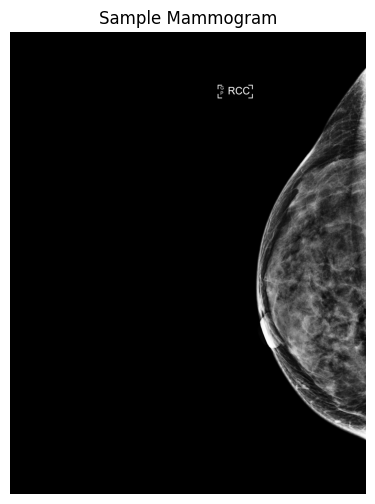

In [10]:
import pydicom
import matplotlib.pyplot as plt

sample_path = df_clean["full_image_path"].iloc[0]

dicom = pydicom.dcmread(sample_path)

image = dicom.pixel_array

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title("Sample Mammogram")
plt.axis("off")
plt.show()

In [11]:
!pip install -q pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg python-gdcm opencv-python tqdm

In [12]:

import cv2
from tqdm import tqdm

PROCESSED_DIR = os.path.join(BASE_DIR, "processed_images_512")
os.makedirs(PROCESSED_DIR, exist_ok=True)

def normalize_to_uint8(image):
    image = image.astype(np.float32)

    min_val = np.min(image)
    max_val = np.max(image)

    if max_val > min_val:
        image = (image - min_val) / (max_val - min_val)
    else:
        image = np.zeros_like(image)

    image = (image * 255).astype(np.uint8)
    return image


def resize_with_padding(image, target_size=512):
    h, w = image.shape

    scale = target_size / max(h, w)
    new_h = int(h * scale)
    new_w = int(w * scale)

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    padded = np.zeros((target_size, target_size), dtype=np.uint8)

    top = (target_size - new_h) // 2
    left = (target_size - new_w) // 2

    padded[top:top + new_h, left:left + new_w] = resized

    return padded


def dicom_to_png(dicom_path, output_path, target_size=512):
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array

    image = normalize_to_uint8(image)
    image = resize_with_padding(image, target_size=target_size)

    cv2.imwrite(output_path, image)

In [13]:
processed_paths = []

for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    patient_id = str(row["empi_anon"])
    exam_id = str(row["acc_anon"])
    view = str(row["ViewPosition"])
    side = str(row["ImageLateralityFinal"])

    output_name = f"{patient_id}_{exam_id}_{side}_{view}_{idx}.png"
    output_path = os.path.join(PROCESSED_DIR, output_name)

    if not os.path.exists(output_path):
        dicom_to_png(row["full_image_path"], output_path, target_size=512)

    processed_paths.append(output_path)

df_clean["processed_image_path"] = processed_paths

print("Conversion completed.")
print("Processed images:", len(df_clean))
print("Saved to:", PROCESSED_DIR)

100%|██████████| 1038/1038 [41:15<00:00,  2.38s/it]

Conversion completed.
Processed images: 1038
Saved to: /content/drive/MyDrive/EMBED/processed_images_512


In [14]:
# Keep only important columns

final_columns = [
    "empi_anon",
    "acc_anon",
    "study_date_anon",
    "ViewPosition",
    "ImageLateralityFinal",
    "processed_image_path",
    "future_risk_label",
    "days_to_cancer",
    "risk_1yr",
    "risk_2yr",
    "risk_3yr",
    "risk_4yr",
    "risk_5yr"
]

final_df = df_clean[final_columns].copy()

print(final_df.shape)

final_df.head()

(1038, 13)


,empi_anon,acc_anon,study_date_anon,ViewPosition,ImageLateralityFinal,processed_image_path,future_risk_label,days_to_cancer,risk_1yr,risk_2yr,risk_3yr,risk_4yr,risk_5yr
0,57769289,3512912135438605,2016-06-15 00:00:00,CC,R,/content/drive/MyDrive/EMBED/processed_images_...,1,412.0,0,1,1,1,1
1,57769289,3504436559522696,2017-01-21 00:00:00,MLO,L,/content/drive/MyDrive/EMBED/processed_images_...,1,412.0,0,1,1,1,1
2,57769289,3504436559522696,2017-01-21 00:00:00,CC,L,/content/drive/MyDrive/EMBED/processed_images_...,1,412.0,0,1,1,1,1
3,57769289,3512912135438605,2016-06-15 00:00:00,MLO,L,/content/drive/MyDrive/EMBED/processed_images_...,1,412.0,0,1,1,1,1
4,57769289,6528636244388176,2016-07-20 00:00:00,CC,L,/content/drive/MyDrive/EMBED/processed_images_...,1,412.0,0,1,1,1,1


In [15]:
FINAL_CSV_PATH = os.path.join(
    BASE_DIR,
    "embed_future_risk_dataset_512.csv"
)

final_df.to_csv(FINAL_CSV_PATH, index=False)

print("Saved final dataset CSV:")
print(FINAL_CSV_PATH)

Saved final dataset CSV:
/content/drive/MyDrive/EMBED/embed_future_risk_dataset_512.csv
